In [ ]:
# Cell 1: Install libraries (Colab)

import yfinance as yf
import pandas as pd
import numpy as np

# Nifty 50 tickers (Yahoo Finance uses .NS suffix for NSE-listed stocks)
tickers = [
    "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS",      # Safe
    "TCS.NS", "RELIANCE.NS", "ICICIBANK.NS",        # Moderate
    "M&M.NS", "ADANIENT.NS", "BAJFINANCE.NS", "TATASTEEL.NS"  # Risky
]

data = yf.download(tickers, start="2019-01-01", end="2024-12-31")["Close"]
data.head()

/tmp/ipykernel_852/3307223982.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2019-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  10 of 10 completed


Ticker,ADANIENT.NS,BAJFINANCE.NS,HINDUNILVR.NS,ICICIBANK.NS,ITC.NS,M&M.NS,NESTLEIND.NS,RELIANCE.NS,TATASTEEL.NS,TCS.NS
Date,,,,,,,,,,
2019-01-01,155.236969,257.620483,1591.314331,350.957001,196.502670,716.987549,499.269897,496.196381,41.323273,1561.000366
2019-01-02,152.867691,253.470428,1576.736450,351.777130,195.042999,687.644409,500.192291,489.733917,39.552559,1577.818115
2019-01-03,150.547775,250.769897,1580.093872,350.474579,193.826584,665.949707,507.977112,483.691925,38.559032,1558.662231
2019-01-04,150.597122,249.785751,1574.173950,352.356049,195.286301,672.717651,491.843109,486.303467,39.071823,1539.711792
2019-01-07,149.313766,247.608902,1577.045410,354.768127,195.772842,676.379883,488.892395,489.003510,38.899555,1556.980713


In [11]:
# Cell 2: Calculate expected returns and covariance matrix
from pypfopt import expected_returns, risk_models

# Expected annual returns (mean historical return, annualized)
mu = expected_returns.mean_historical_return(data)

# Covariance matrix (annualized, using sample covariance)
S = risk_models.sample_cov(data)

print("Expected Annual Returns:\n")
print(mu.sort_values(ascending=True))

print("\n\nCovariance Matrix:\n")
S

Expected Annual Returns:

Ticker
HINDUNILVR.NS    0.063019
NESTLEIND.NS     0.136461
ITC.NS           0.139709
RELIANCE.NS      0.162433
TCS.NS           0.168558
BAJFINANCE.NS    0.179961
TATASTEEL.NS     0.217331
ICICIBANK.NS     0.247448
M&M.NS           0.272388
ADANIENT.NS      0.615326
dtype: float64


Covariance Matrix:



Ticker,ADANIENT.NS,BAJFINANCE.NS,HINDUNILVR.NS,ICICIBANK.NS,ITC.NS,M&M.NS,NESTLEIND.NS,RELIANCE.NS,TATASTEEL.NS,TCS.NS
Ticker,,,,,,,,,,
ADANIENT.NS,0.285181,0.070766,0.021682,0.056570,0.028287,0.057055,0.020180,0.051240,0.064854,0.029705
BAJFINANCE.NS,0.070766,0.138868,0.025796,0.068099,0.028509,0.053844,0.021128,0.042647,0.057909,0.023347
HINDUNILVR.NS,0.021682,0.025796,0.053762,0.018305,0.016099,0.016661,0.029899,0.020899,0.015246,0.016566
ICICIBANK.NS,0.056570,0.068099,0.018305,0.097401,0.026219,0.045886,0.018364,0.037386,0.052159,0.021375
ITC.NS,0.028287,0.028509,0.016099,0.026219,0.062973,0.025557,0.012325,0.020691,0.030501,0.013243
M&M.NS,0.057055,0.053844,0.016661,0.045886,0.025557,0.111578,0.018403,0.035865,0.049612,0.022997
NESTLEIND.NS,0.020180,0.021128,0.029899,0.018364,0.012325,0.018403,0.050234,0.020389,0.016664,0.013150
RELIANCE.NS,0.051240,0.042647,0.020899,0.037386,0.020691,0.035865,0.020389,0.085901,0.042834,0.024489
TATASTEEL.NS,0.064854,0.057909,0.015246,0.052159,0.030501,0.049612,0.016664,0.042834,0.142280,0.028072


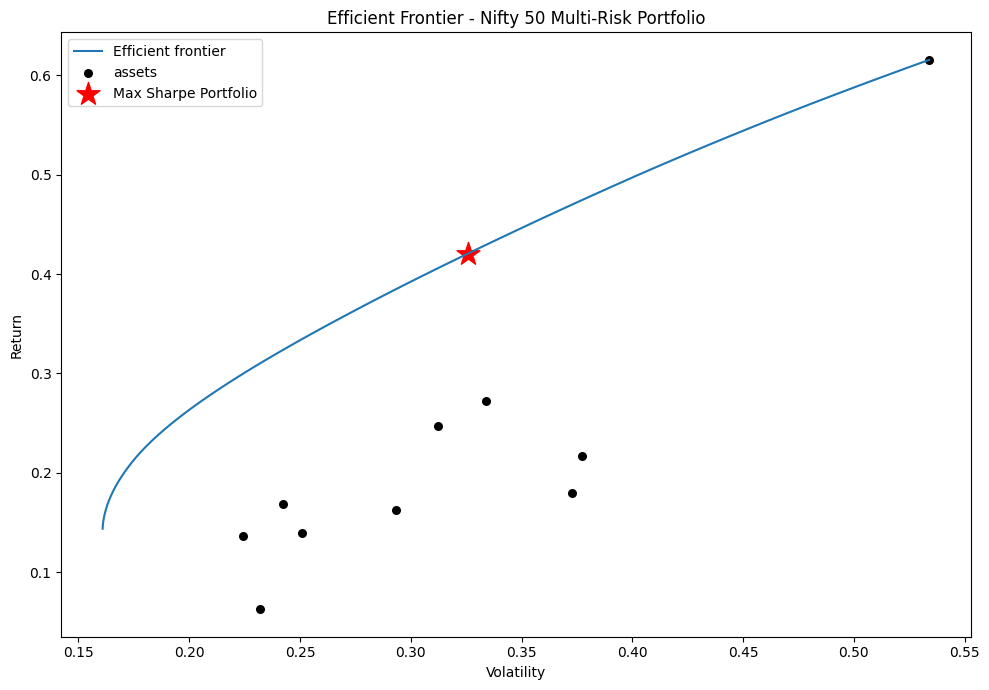

In [13]:
# Cell 4: Plot the Efficient Frontier
import matplotlib.pyplot as plt
from pypfopt import CLA, plotting

# Generate the efficient frontier using CLA (Critical Line Algorithm)
ef_plot = EfficientFrontier(mu, S)

fig, ax = plt.subplots(figsize=(10, 7))
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

# Mark our Max Sharpe portfolio
ax.scatter(0.3258, 0.4206, marker="*", s=300, c="red", label="Max Sharpe Portfolio")

ax.set_title("Efficient Frontier - Nifty 50 Multi-Risk Portfolio")
ax.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

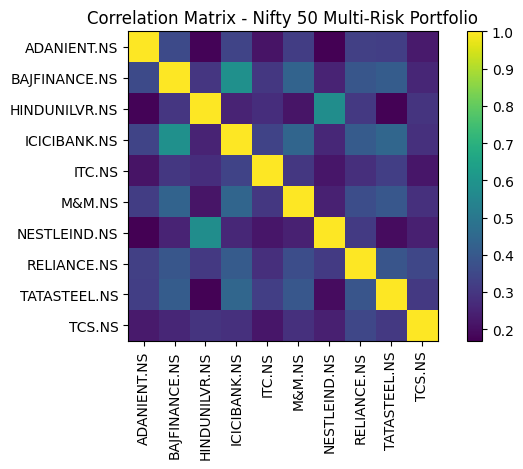

In [20]:
# Cell 4b: Correlation Heatmap (fixed)
from pypfopt import plotting

plt.figure(figsize=(10, 8))
plotting.plot_covariance(S, plot_correlation=True)
plt.title("Correlation Matrix - Nifty 50 Multi-Risk Portfolio")
plt.tight_layout()
plt.show()